In [1]:
# tumor_identification_metrics.ipynb - plot metrics (F1 score etc) of tumor identification.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.patches import Patch

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/analysis/tumor_identification/with_ref'
with_ref = 'with_ref'

## Merge metrics from multiple experiments into one single file.

In [4]:
run_id_list = sorted([d for d in os.listdir(root_dir) if d.endswith('t')])
run_id_list

['100n900t',
 '10n990t',
 '300n700t',
 '30n970t',
 '500n500t',
 '700n300t',
 '900n100t',
 '970n30t',
 '990n10t',
 '997n3t']

In [5]:
dat = None
for run_id in run_id_list:
    print("processing '%s' ..." % run_id)
    run_dir = os.path.join(root_dir, run_id)
    metric_fn = os.path.join(run_dir, 'tumor_identification/%s/2_metric/metrics.tsv' % \
                            (with_ref, ))
    if not os.path.exists(metric_fn):
        print("[W] file '%s' does not exist!" % metric_fn)
        continue
    df = pd.read_csv(metric_fn, sep = '\t')
    df['run_id'] = run_id
    if dat is None:
        dat = df
    else:
        dat = pd.concat([dat, df], ignore_index = True)
    print("dat shape: %s" % str(dat.shape))
dat

processing '100n900t' ...
dat shape: (25, 4)
processing '10n990t' ...
dat shape: (50, 4)
processing '300n700t' ...
dat shape: (75, 4)
processing '30n970t' ...
dat shape: (100, 4)
processing '500n500t' ...
dat shape: (125, 4)
processing '700n300t' ...
dat shape: (150, 4)
processing '900n100t' ...
dat shape: (170, 4)
processing '970n30t' ...
dat shape: (185, 4)
processing '990n10t' ...
dat shape: (200, 4)
processing '997n3t' ...
dat shape: (215, 4)


,tool,metric,value,run_id
0,CalicoST,accuracy,0.997000,100n900t
1,CopyKAT,accuracy,1.000000,100n900t
2,inferCNV,accuracy,1.000000,100n900t
3,Numbat,accuracy,1.000000,100n900t
4,XClone,accuracy,0.988000,100n900t
...,...,...,...,...
210,inferCNV,F1,1.000000,997n3t
211,XClone,F1,0.009288,997n3t
212,CopyKAT,ARI,0.002309,997n3t
213,inferCNV,ARI,1.000000,997n3t


In [6]:
dat['tool'] = dat['tool'].replace({'CopyKat':'CopyKAT', 'inferCNV':'InferCNV'})
dat

,tool,metric,value,run_id
0,CalicoST,accuracy,0.997000,100n900t
1,CopyKAT,accuracy,1.000000,100n900t
2,InferCNV,accuracy,1.000000,100n900t
3,Numbat,accuracy,1.000000,100n900t
4,XClone,accuracy,0.988000,100n900t
...,...,...,...,...
210,InferCNV,F1,1.000000,997n3t
211,XClone,F1,0.009288,997n3t
212,CopyKAT,ARI,0.002309,997n3t
213,InferCNV,ARI,1.000000,997n3t


In [7]:
metric_fn = os.path.join(out_dir, 'tumor_identification.%s.metrics.tsv' % with_ref)
dat.to_csv(
    metric_fn,
    sep = '\t',
    index = False
)

In [8]:
dat

,tool,metric,value,run_id
0,CalicoST,accuracy,0.997000,100n900t
1,CopyKAT,accuracy,1.000000,100n900t
2,InferCNV,accuracy,1.000000,100n900t
3,Numbat,accuracy,1.000000,100n900t
4,XClone,accuracy,0.988000,100n900t
...,...,...,...,...
210,InferCNV,F1,1.000000,997n3t
211,XClone,F1,0.009288,997n3t
212,CopyKAT,ARI,0.002309,997n3t
213,InferCNV,ARI,1.000000,997n3t


## Plot

In [9]:
dat = pd.read_csv(
    metric_fn,
    sep = '\t'
)
dat

,tool,metric,value,run_id
0,CalicoST,accuracy,0.997000,100n900t
1,CopyKAT,accuracy,1.000000,100n900t
2,InferCNV,accuracy,1.000000,100n900t
3,Numbat,accuracy,1.000000,100n900t
4,XClone,accuracy,0.988000,100n900t
...,...,...,...,...
210,InferCNV,F1,1.000000,997n3t
211,XClone,F1,0.009288,997n3t
212,CopyKAT,ARI,0.002309,997n3t
213,InferCNV,ARI,1.000000,997n3t


In [10]:
dat['run_id_raw'] = dat['run_id']
dat_raw = dat.copy()
dat = dat.loc[dat['run_id_raw'] != '997n3t'].copy()
dat['run_id'] = dat['run_id'].map({
    '10n990t':'99',
    '30n970t':'97',
    '100n900t':'90',
    '300n700t':'70',
    '500n500t':'50',
    '700n300t':'30',
    '900n100t':'10',
    '970n30t':'3',
    '990n10t':'1'
})
dat['run_id'] = pd.Categorical(
    dat['run_id'], 
    categories = [str(i) for i in (99, 97, 90, 70, 50, 30, 10, 3, 1)],
    ordered = True
)
dat

,tool,metric,value,run_id,run_id_raw
0,CalicoST,accuracy,0.997000,90,100n900t
1,CopyKAT,accuracy,1.000000,90,100n900t
2,InferCNV,accuracy,1.000000,90,100n900t
3,Numbat,accuracy,1.000000,90,100n900t
4,XClone,accuracy,0.988000,90,100n900t
...,...,...,...,...,...
195,InferCNV,F1,1.000000,1,990n10t
196,XClone,F1,0.041929,1,990n10t
197,CopyKAT,ARI,-0.011639,1,990n10t
198,InferCNV,ARI,1.000000,1,990n10t


In [11]:
dat = dat[['tool', 'metric', 'run_id', 'value']].pivot(
    index = ['run_id', 'tool'],
    columns = 'metric',
    values = 'value'
).reset_index()
dat

metric,run_id,tool,ARI,F1,accuracy,precision,recall
0,99,CalicoST,0.950904,0.999495,0.999000,1.000000,0.998990
1,99,CopyKAT,0.950904,0.999495,0.999000,1.000000,0.998990
2,99,InferCNV,0.005101,0.716785,0.563000,1.000000,0.558586
3,99,Numbat,1.000000,1.000000,1.000000,1.000000,1.000000
4,99,XClone,0.732124,0.996452,0.993000,1.000000,0.992929
5,97,CalicoST,0.962439,0.998969,0.997998,0.997940,1.000000
6,97,CopyKAT,1.000000,1.000000,1.000000,1.000000,1.000000
7,97,InferCNV,1.000000,1.000000,1.000000,1.000000,1.000000
8,97,Numbat,1.000000,1.000000,1.000000,1.000000,1.000000
9,97,XClone,0.875059,0.996386,0.992993,0.996901,0.995872


In [12]:
def plot_metrics(df, metric, metric_label, figsize = (9, 5), fontsize = 10, total_bar_width = 0.8, ymin = 0):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'F1', 'run_id'.
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric, 'run_id'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")
    
    # Ensure consistent ordering
    df = df.copy()
    df = df.sort_values(['run_id', 'tool']).reset_index(drop = True)

    # Pivot to get metric value per (run_id, tool, cna_type)
    pivot = df.pivot_table(
        index = 'run_id',
        columns = 'tool',
        values = metric,
        fill_value = -2
    )

    # Extract unique groups
    tool_order = ['InferCNV', 'CopyKAT', 'Numbat', 'XClone', 'CalicoST']
    run_ids = pivot.index.get_level_values('run_id').unique()
    tools = tool_order
    n_runs, n_tools = len(run_ids), len(tools)

    # Bar layout
    bar_width = total_bar_width / n_tools
    x_centers = np.arange(n_runs)

    # Colors
    tool_palette = [
        '#56B4E9',    # InferCNV
        '#E69F00',    # CopyKAT
        '#0072B2',    # Numbat
        '#F0E442',    # XClone
        '#D55E00'     # CalicoST
    ]
    tool_colors = [tool_palette[i % 100] for i in range(n_tools)]


    # Create plot
    fig, ax = plt.subplots(figsize = figsize)

    # Draw stacked bars
    y_star = 0.036
    for i, tool in enumerate(tools):
        for j, run in enumerate(run_ids):
            has_output = True
            if run in pivot.index:
                h = pivot.loc[run, tool]
                if h < -1:
                    has_output = False
            else:
                has_output = False
            x_pos = x_centers[j] + i * bar_width
            if has_output:
                ax.bar(
                    x_pos,
                    h,
                    bottom = 0,
                    width = bar_width,
                    color = tool_colors[i],
                    edgecolor = None,
                    linewidth = 0.5,
                    label = tool
                )
            else:
                ax.text(
                    x_pos, y_star,
                    '*', 
                    ha = 'center', va = 'top',
                    fontsize = fontsize - 2,
                    color = 'black',
                    weight = 'bold'
                )

    # Main axis styling
    ax.set_xticks(x_centers + bar_width * (n_tools - 1) / 2)
    ax.set_xticklabels(run_ids)
    ax.set_xlabel('Tumor percentage (%)', size = fontsize + 1)
    ax.set_ylabel(metric_label, fontsize = fontsize + 1)
    ax.set_xlim(0 - bar_width, n_runs - 1 + bar_width * n_tools)
    ax.set_ylim(ymin, 1.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Title (lowered to avoid top panel)
    #fig.suptitle('AUROC by Run, Tool, and CNA Type', y=0.95)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #legend = fig.legend(
    #    [by_label[t] for t in tool_order], 
    #    tool_order, 
    #    title = None, 
    #    loc = 'upper center',
    #    frameon = False,
    #    ncol = 3,
    #    fontsize = fontsize,
    #    title_fontsize = fontsize,
    #    alignment = 'left',
    #    bbox_to_anchor = (0.53, 0.05)
    #)
    legend = fig.legend(
        [by_label[t] for t in tool_order], 
        tool_order, 
        title = 'Tool', 
        loc = 'upper left',
        frameon = False,
        fontsize = fontsize - 1,
        title_fontsize = fontsize - 1,
        alignment = 'left',
        bbox_to_anchor = (0.97, 0.84)
    )

    plt.tight_layout()
    return fig, ax

### Plot F1

In [13]:
metric = 'F1'
metric_label = 'F1 score'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,F1,run_id
0,CalicoST,0.999495,99
1,CopyKAT,0.999495,99
2,InferCNV,0.716785,99
3,Numbat,1.000000,99
4,XClone,0.996452,99


/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


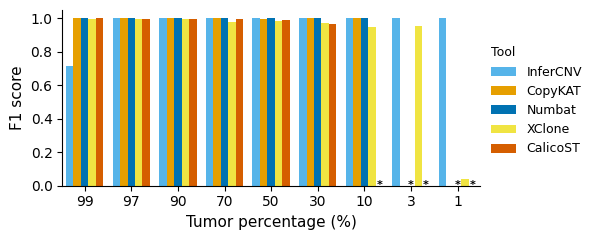

In [14]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5, 2.5), fontsize = 10)

In [15]:
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


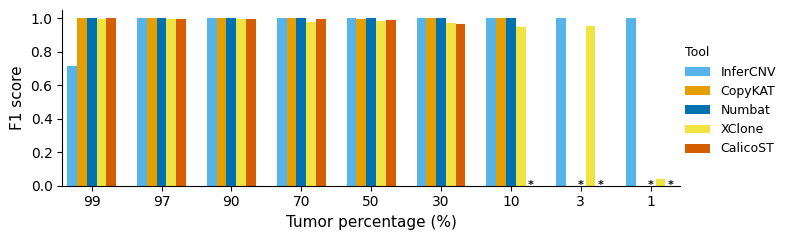

In [16]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (7, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot accuracy

In [17]:
metric = 'accuracy'
metric_label = 'Accuracy'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,accuracy,run_id
0,CalicoST,0.999,99
1,CopyKAT,0.999,99
2,InferCNV,0.563,99
3,Numbat,1.000,99
4,XClone,0.993,99


/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


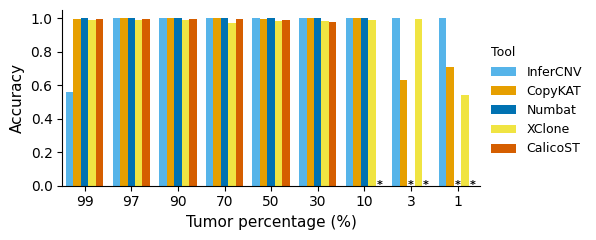

In [18]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5, 2.5), fontsize = 10)

In [19]:
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


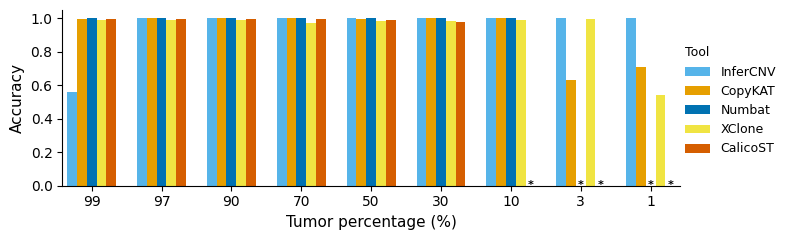

In [20]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (7, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot precision

In [21]:
metric = 'precision'
metric_label = 'Precision'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,precision,run_id
0,CalicoST,1.0,99
1,CopyKAT,1.0,99
2,InferCNV,1.0,99
3,Numbat,1.0,99
4,XClone,1.0,99


/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


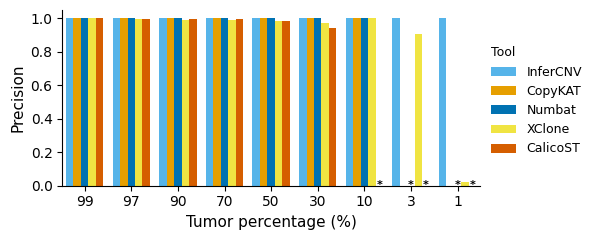

In [22]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


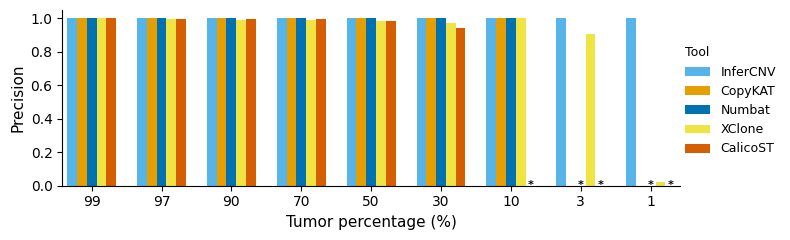

In [23]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (7, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot recall

In [24]:
metric = 'recall'
metric_label = 'Recall'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,recall,run_id
0,CalicoST,0.998990,99
1,CopyKAT,0.998990,99
2,InferCNV,0.558586,99
3,Numbat,1.000000,99
4,XClone,0.992929,99


/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


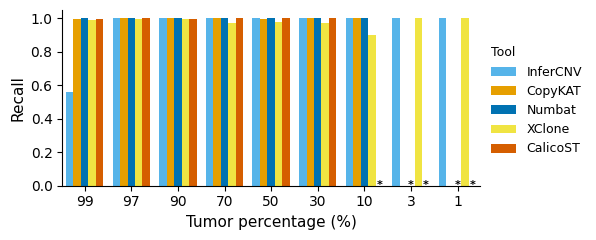

In [25]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


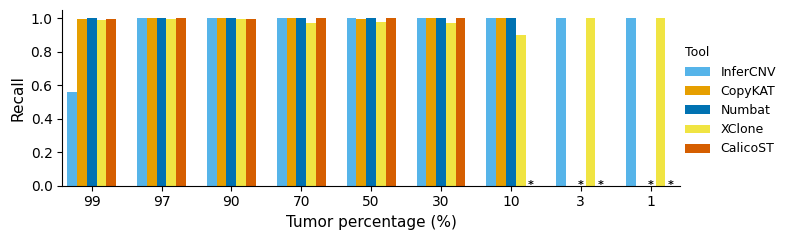

In [26]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (7, 2.5), fontsize = 10, total_bar_width = 0.7)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot ARI

In [27]:
metric = 'ARI'
metric_label = 'ARI'    # Adjusted Rand Index
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,ARI,run_id
0,CalicoST,0.950904,99
1,CopyKAT,0.950904,99
2,InferCNV,0.005101,99
3,Numbat,1.000000,99
4,XClone,0.732124,99


In [28]:
df['ARI'].min()

-0.0252747435634281

/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


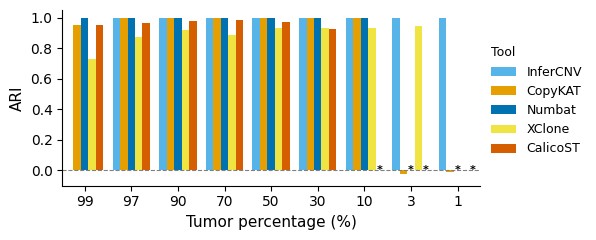

In [29]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5, 2.5), fontsize = 10, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_55124/2367630186.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


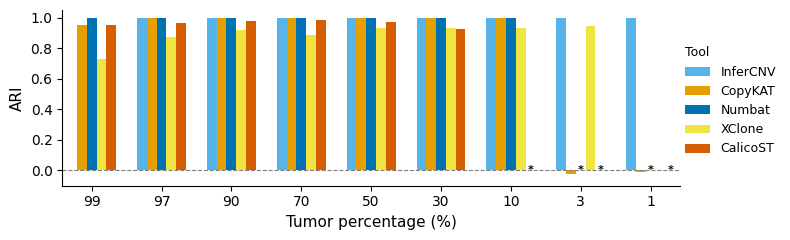

In [30]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (7, 2.5), fontsize = 10, total_bar_width = 0.7, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

## Plot n=3 tumor spots

In [31]:
def plot_metrics(df, metric, metric_label, figsize = (9, 5), fontsize = 10):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'F1'.
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")

    # Extract unique groups
    tool_order = ['InferCNV', 'CopyKAT', 'Numbat', 'XClone', 'CalicoST']
    df['tool'] = pd.Categorical(df['tool'], categories = tool_order, ordered = True)
    df = df.sort_values('tool')

    # Colors
    tool_colors = [plt.cm.tab10(i % 10) for i in range(len(tool_order))]

    # Create plot
    fig, ax = plt.subplots(figsize = figsize)

    # Draw stacked bars
    y_star = 0.05
    bar_width = 0.6
    j = 0
    for i, tool in enumerate(tool_order):
        has_output = True
        if tool in df['tool'].to_numpy():
            h = df[metric].iloc[j]
            if h < 0:
                has_output = False
            j += 1
        else:
            has_output = False
        x_pos = i
        if has_output:
            ax.bar(
                x_pos,
                h,
                bottom = 0,
                width = bar_width,
                #color = tool_colors[i],
                color = tool_colors[0],
                edgecolor = None,
                linewidth = 0.5,
                label = tool
            )
        else:
            ax.text(
                x_pos, y_star,
                '*', 
                ha = 'center', va = 'top',
                fontsize = fontsize - 1,
                color = 'black',
                weight = 'bold'
            )

    # Main axis styling
    ax.set_xticks(range(len(tool_order)))
    ax.set_xticklabels(tool_order, rotation = 45, ha = 'right', rotation_mode = 'anchor')
    ax.set_xlim(None, len(tool_order)-1+bar_width/2+0.01)
    ax.set_xlabel(None)
    ax.set_ylabel(metric_label, fontsize = fontsize + 1)
    ax.set_ylim(0, 1.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    return fig, ax

In [32]:
dat = dat_raw.loc[dat_raw['run_id_raw'] == '997n3t'].copy()
#dat = dat.merge(
#    pd.DataFrame(data = dict(tool = ['InferCNV', 'CopyKAT', 'Numbat', 'XClone', 'CalicoST'])),
#    on = 'tool',
#    how = 'right'
#)
dat['run_id'] = dat['run_id'].map({
    '997n3t':'3'
})
dat

,tool,metric,value,run_id,run_id_raw
200,CopyKAT,accuracy,0.417000,3,997n3t
201,InferCNV,accuracy,1.000000,3,997n3t
202,XClone,accuracy,0.360000,3,997n3t
203,CopyKAT,precision,0.000000,3,997n3t
204,InferCNV,precision,1.000000,3,997n3t
205,XClone,precision,0.004666,3,997n3t
206,CopyKAT,recall,0.000000,3,997n3t
207,InferCNV,recall,1.000000,3,997n3t
208,XClone,recall,1.000000,3,997n3t
209,CopyKAT,F1,0.000000,3,997n3t


In [33]:
dat = dat[['tool', 'metric', 'run_id', 'value']].pivot(
    index = ['run_id', 'tool'],
    columns = 'metric',
    values = 'value'
).reset_index()
dat

metric,run_id,tool,ARI,F1,accuracy,precision,recall
0,3,CopyKAT,0.002309,0.000000,0.417,0.000000,0.0
1,3,InferCNV,1.000000,1.000000,1.000,1.000000,1.0
2,3,XClone,-0.002642,0.009288,0.360,0.004666,1.0


In [34]:
metric = 'F1'
metric_label = 'F1 score'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,F1,run_id
0,CopyKAT,0.000000,3
1,InferCNV,1.000000,3
2,XClone,0.009288,3


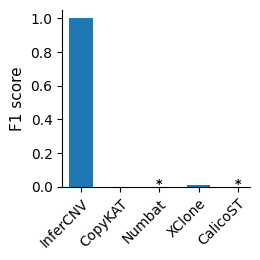

In [35]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.7), fontsize = 10)

In [36]:
fn = os.path.join(out_dir, 'tumor_identification.n3.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

In [37]:
metric = 'accuracy'
metric_label = 'Accuracy'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,accuracy,run_id
0,CopyKAT,0.417,3
1,InferCNV,1.000,3
2,XClone,0.360,3


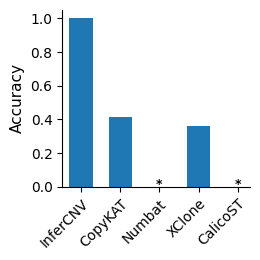

In [38]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (2.7, 2.7), fontsize = 10)

In [39]:
fn = os.path.join(out_dir, 'tumor_identification.n3.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')